In [2]:
import pandas as pd
df = pd.read_csv("../data/ratings.csv")
movies = pd.read_csv("../data/movies.csv")

In [3]:
df.head()

,user_id,movie_id,rating,date
0,1488844,1,3,2005-09-06
1,822109,1,5,2005-05-13
2,885013,1,4,2005-10-19
3,30878,1,4,2005-12-26
4,823519,1,3,2004-05-03


In [4]:
movies.head()

,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [5]:
df.shape


(24053764, 4)

In [6]:
movies.shape

(17770, 3)

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

print(train_df.shape)
print(test_df.shape)

(19243011, 4)
(4810753, 4)


In [8]:
movie_stats = (
    train_df.groupby("movie_id")
    .agg(
        avg_rating=("rating","mean"),
        num_ratings=("rating","count")
    )
    .reset_index()
)

In [9]:
import numpy as np

movie_stats["score"] = (
    movie_stats["avg_rating"]
    * np.log1p(movie_stats["num_ratings"])
)

In [10]:
movie_stats=movie_stats.sort_values(
    "score",
    ascending=False
).head(20)

In [11]:
movie_stats.merge(
    movies,
    on="movie_id"
)

,movie_id,avg_rating,num_ratings,score,year,title
0,2452,4.435667,119931,51.873709,2001.0,Lord of the Rings: The Fellowship of the Ring
1,3962,4.415162,112686,51.358801,2003.0,Finding Nemo (Widescreen)
2,4306,4.323536,120784,50.593015,1999.0,The Sixth Sense
3,2782,4.293238,108366,49.772702,1995.0,Braveheart
4,2862,4.311795,102811,49.760954,1991.0,The Silence of the Lambs
5,1905,4.155122,155149,49.662630,2003.0,Pirates of the Caribbean: The Curse of the Bla...
6,3938,4.144203,123368,48.582220,2004.0,Shrek 2
7,3290,4.406132,57309,48.274594,1974.0,"The Godfather, Part II"
8,886,4.186593,86922,47.613188,2004.0,Ray
9,1220,4.011546,107401,46.471083,2004.0,Man on Fire


In [12]:
movie_stats.head()

,movie_id,avg_rating,num_ratings,score
2451,2452,4.435667,119931,51.873709
3961,3962,4.415162,112686,51.358801
4305,4306,4.323536,120784,50.593015
2781,2782,4.293238,108366,49.772702
2861,2862,4.311795,102811,49.760954


In [13]:
def popularity_recommend(user_id, top_k=10):
    seen_movies = set(
        train_df.loc[
            train_df["user_id"] == user_id,
            "movie_id"
        ]
    )

    recommendations = movie_stats[
        ~movie_stats["movie_id"].isin(seen_movies)
    ]

    recommendations = recommendations.merge(
        movies,
        on="movie_id",
        how="left"
    )

    return recommendations[
        [
            "title",
            "year",
            "avg_rating",
            "num_ratings",
            "score"
        ]
    ].head(top_k)

In [14]:
popularity_recommend(1)

,title,year,avg_rating,num_ratings,score
0,Lord of the Rings: The Fellowship of the Ring,2001.0,4.435667,119931,51.873709
1,Finding Nemo (Widescreen),2003.0,4.415162,112686,51.358801
2,The Sixth Sense,1999.0,4.323536,120784,50.593015
3,Braveheart,1995.0,4.293238,108366,49.772702
4,The Silence of the Lambs,1991.0,4.311795,102811,49.760954
5,Pirates of the Caribbean: The Curse of the Bla...,2003.0,4.155122,155149,49.662630
6,Shrek 2,2004.0,4.144203,123368,48.582220
7,"The Godfather, Part II",1974.0,4.406132,57309,48.274594
8,Ray,2004.0,4.186593,86922,47.613188
9,Man on Fire,2004.0,4.011546,107401,46.471083


# Item Based Collaborative Filtering 


In [16]:
user_counts = df.groupby("user_id").size()

user_counts

user_id
6          153
7          195
8           21
10          49
25           4
          ... 
2649404     12
2649409     10
2649421      3
2649426     74
2649429     62
Length: 470758, dtype: int64

In [27]:
active_users = user_counts[user_counts >= 100].index

small_df = df[df["user_id"].isin(active_users)]

In [28]:
small_df.shape

(13254584, 4)

In [29]:
print(small_df["user_id"].nunique())
print(small_df["movie_id"].nunique())

71241
4499


In [55]:
sample_users = (
    small_df["user_id"]
    .drop_duplicates()
    .sample(5000, random_state=42)
)

cf_df = small_df[
    small_df["user_id"].isin(sample_users)
]
print(cf_df["user_id"].nunique())
print(cf_df["movie_id"].nunique())
print(cf_df.shape)
movie_counts = cf_df.groupby("movie_id").size()
print(movie_counts.shape[0])

5000
4491
(936009, 4)
4491


In [56]:
movie_counts = cf_df.groupby("movie_id").size()


popular_movies = movie_counts[
    movie_counts >= 40
].index

cf_df = cf_df[
    cf_df["movie_id"].isin(popular_movies)
]
print(movie_counts.shape[0])

4491


In [57]:
print(cf_df["user_id"].nunique())
print(cf_df["movie_id"].nunique())
print(cf_df.shape)

5000
1813
(901682, 4)


In [58]:
user_movie = cf_df.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

print(user_movie.shape)

(5000, 1813)


In [59]:
user_movie

movie_id,3,8,16,17,18,24,25,26,28,30,...,4483,4484,4485,4488,4489,4490,4492,4493,4496,4497
user_id,,,,,,,,,,,,,,,,,,,,,
1533,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
3101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3321,NaN,1.0,3.0,2.0,NaN,1.0,NaN,NaN,4.0,5.0,...,NaN,4.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645868,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2646626,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN
2647661,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
user_movie_filled = user_movie.fillna(0)

In [61]:
movie_user = user_movie_filled.T

In [62]:
movie_user

user_id,1533,1738,2787,3101,3321,3461,4753,5430,5530,5916,...,2643057,2643193,2643787,2645035,2645399,2645868,2646626,2647661,2648465,2648572
movie_id,,,,,,,,,,,,,,,,,,,,,
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
17,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4492,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,4.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
4493,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
from sklearn.metrics.pairwise import cosine_similarity

movie_similarity = cosine_similarity(movie_user)

In [64]:
movie_similarity

array([[1.        , 0.07035304, 0.03035815, ..., 0.07458787, 0.20439784,
        0.05577208],
       [0.07035304, 1.        , 0.054327  , ..., 0.07219927, 0.14111267,
        0.05489337],
       [0.03035815, 0.054327  , 1.        , ..., 0.08744296, 0.05120816,
        0.05742333],
       ...,
       [0.07458787, 0.07219927, 0.08744296, ..., 1.        , 0.08263017,
        0.03815711],
       [0.20439784, 0.14111267, 0.05120816, ..., 0.08263017, 1.        ,
        0.10694153],
       [0.05577208, 0.05489337, 0.05742333, ..., 0.03815711, 0.10694153,
        1.        ]], shape=(1813, 1813))

In [65]:
similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user.index,
    columns=movie_user.index
)
similarity_df.head()

movie_id,3,8,16,17,18,24,25,26,28,30,...,4483,4484,4485,4488,4489,4490,4492,4493,4496,4497
movie_id,,,,,,,,,,,,,,,,,,,,,
3,1.000000,0.070353,0.030358,0.017160,0.129510,0.016505,0.087535,0.021207,0.044928,0.089219,...,0.038621,0.016927,0.037241,0.145751,0.048639,0.068685,0.022612,0.074588,0.204398,0.055772
8,0.070353,1.000000,0.054327,0.048452,0.152053,0.024368,0.051322,0.053577,0.120600,0.217200,...,0.063683,0.038167,0.040954,0.184457,0.064348,0.083272,0.057156,0.072199,0.141113,0.054893
16,0.030358,0.054327,1.000000,0.110134,0.085347,0.124269,0.052297,0.067624,0.121819,0.099721,...,0.067741,0.101169,0.124122,0.091100,0.107849,0.096102,0.099527,0.087443,0.051208,0.057423
17,0.017160,0.048452,0.110134,1.000000,0.034065,0.070605,0.017831,0.239880,0.133894,0.193999,...,0.026973,0.060684,0.046984,0.046549,0.045293,0.122307,0.109393,0.072745,0.027421,0.030296
18,0.129510,0.152053,0.085347,0.034065,1.000000,0.054043,0.073801,0.034436,0.179435,0.255176,...,0.050583,0.064461,0.106507,0.287499,0.058103,0.129049,0.073278,0.099966,0.285799,0.119870


In [66]:
movie_id = 1905
similar_movies = similarity_df[movie_id].sort_values(
    ascending=False
)

similar_movies.head(10)

movie_id
1905    1.000000
2452    0.883148
4306    0.872698
3962    0.860805
3938    0.843179
3860    0.842542
2782    0.839289
2862    0.838931
4432    0.823174
571     0.811035
Name: 1905, dtype: float64

In [67]:
movie_lookup = dict(
    zip(movies.movie_id, movies.title)
)

In [68]:
for m in similar_movies.index[:10]:
    print(movie_lookup.get(m))

Pirates of the Caribbean: The Curse of the Black Pearl
Lord of the Rings: The Fellowship of the Ring
The Sixth Sense
Finding Nemo (Widescreen)
Shrek 2
Bruce Almighty
Braveheart
The Silence of the Lambs
The Italian Job
American Beauty


In [69]:
user_id = cf_df["user_id"].iloc[0]
watched = user_movie.loc[user_id].dropna()

In [70]:
watched

movie_id
3       4.0
108     3.0
117     2.0
143     3.0
175     4.0
       ... 
4450    4.0
4472    3.0
4479    4.0
4493    4.0
4496    4.0
Name: 2031561, Length: 176, dtype: float64

In [79]:
movie_lookup = dict(
    zip(movies["movie_id"], movies["title"])
)

def recommend(user_id, k=10, n_neighbors=50):

    watched = user_movie.loc[user_id].dropna()

    scores = {}

    for movie_id, rating in watched.items():

        similar_movies = (
            similarity_df[movie_id]
            .sort_values(ascending=False)
            .iloc[1:n_neighbors+1]
        )

        for similar_movie, similarity in similar_movies.items():

            scores[similar_movie] = (
                scores.get(similar_movie, 0)
                + similarity * rating
            )

    for movie_id in watched.index:
        scores.pop(movie_id, None)

    recommendations = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:k]

    return pd.DataFrame([
        {
            "movie_id": movie_id,
            "title": movie_lookup.get(movie_id, "Unknown"),
            "score": score
        }
        for movie_id, score in recommendations
    ])

In [89]:
user_id = user_movie.index[4]


recommend(user_id, 10)

,movie_id,title,score
0,4432,The Italian Job,416.474081
1,1542,Sleepless in Seattle,342.647652
2,1220,Man on Fire,306.472609
3,1145,The Wedding Planner,276.347300
4,2660,When Harry Met Sally,215.680662
5,313,Pay It Forward,198.327096
6,175,Reservoir Dogs,173.168128
7,1144,Fried Green Tomatoes,137.666684
8,2122,Being John Malkovich,133.896713
9,1754,Sixteen Candles,133.299927


# doing on splitted data 

In [177]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    cf_df,
    test_size=0.2,
    random_state=42
)
print(train_df.shape)
test_df.shape

(721345, 4)


(180337, 4)

In [ ]:
user_movie_train = train_df.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

user_movie_filled = user_movie_train.fillna(train_df["rating"].mean())

movie_user = user_movie_filled.T

In [179]:
user_movie_train.shape

(5000, 1813)

In [180]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

movie_similarity = cosine_similarity(movie_user)

similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user.index,
    columns=movie_user.index
)
similarity_df

movie_id,3,8,16,17,18,24,25,26,28,30,...,4483,4484,4485,4488,4489,4490,4492,4493,4496,4497
movie_id,,,,,,,,,,,,,,,,,,,,,
3,1.000000,0.034219,0.018687,0.021669,0.090458,0.020930,0.114924,0.027477,0.036831,0.077849,...,0.027722,0.022366,0.029610,0.132630,0.062471,0.075359,0.020105,0.073081,0.183259,0.052204
8,0.034219,1.000000,0.053386,0.037364,0.144632,0.025606,0.049600,0.032494,0.101324,0.186361,...,0.053165,0.049696,0.047406,0.145531,0.050165,0.066343,0.041579,0.057995,0.114214,0.011507
16,0.018687,0.053386,1.000000,0.106636,0.082689,0.125000,0.034404,0.040451,0.120263,0.084987,...,0.059919,0.122125,0.084386,0.081880,0.080204,0.081442,0.079288,0.071074,0.033763,0.017816
17,0.021669,0.037364,0.106636,1.000000,0.032684,0.050104,0.017731,0.191413,0.107660,0.156161,...,0.032505,0.046330,0.038373,0.033750,0.034009,0.115054,0.109060,0.068328,0.018518,0.018703
18,0.090458,0.144632,0.082689,0.032684,1.000000,0.051736,0.076978,0.023418,0.156288,0.202942,...,0.039351,0.046417,0.089401,0.228497,0.056352,0.115502,0.064653,0.098197,0.209157,0.094545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4490,0.075359,0.066343,0.081442,0.115054,0.115502,0.041257,0.042489,0.139955,0.135427,0.186991,...,0.040736,0.051301,0.065683,0.137285,0.031346,1.000000,0.081402,0.063683,0.070486,0.014968
4492,0.020105,0.041579,0.079288,0.109060,0.064653,0.109450,0.014357,0.162093,0.135905,0.157027,...,0.048324,0.057733,0.084154,0.138997,0.042367,0.081402,1.000000,0.103741,0.018832,0.024524
4493,0.073081,0.057995,0.071074,0.068328,0.098197,0.122325,0.026382,0.105463,0.127113,0.123031,...,0.044738,0.041361,0.116910,0.117274,0.045153,0.063683,0.103741,1.000000,0.068623,0.004554


In [181]:
import numpy as np

def predict_rating(user_id, movie_id, n_neighbors=20):

    # user not in train
    if user_id not in user_movie_train.index:
        return train_df["rating"].mean()

    # movie not in train
    if movie_id not in similarity_df.index:
        return train_df["rating"].mean()

    user_ratings = user_movie_train.loc[user_id]

    rated_movies = user_ratings.dropna()

    numerator = 0
    denominator = 0

    for rated_movie, rating in rated_movies.items():

        # skip same movie
        if rated_movie == movie_id:
            continue

        if rated_movie not in similarity_df.index:
            continue

        similarity = similarity_df.loc[movie_id, rated_movie]

        numerator += similarity * rating
        denominator += abs(similarity)

    if denominator == 0:
        return train_df["rating"].mean()

    return numerator / denominator

In [182]:
test_sample = test_df.sample(
    5000,
    random_state=42
)

In [183]:
actual = []
predicted = []

for _, row in test_sample.iterrows():

    user_id = row["user_id"]
    movie_id = row["movie_id"]

    pred = predict_rating(
        user_id,
        movie_id
    )

    actual.append(row["rating"])
    predicted.append(pred)

In [184]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

print("RMSE =", rmse)

RMSE = 0.9556994988066705


In [185]:
for i in range(10):
    print(
        f"Actual: {actual[i]}, "
        f"Predicted: {predicted[i]:.2f}"
    )

Actual: 2, Predicted: 4.03
Actual: 4, Predicted: 3.23
Actual: 4, Predicted: 3.77
Actual: 3, Predicted: 3.80
Actual: 5, Predicted: 3.72
Actual: 4, Predicted: 3.67
Actual: 5, Predicted: 4.51
Actual: 3, Predicted: 3.11
Actual: 3, Predicted: 3.43
Actual: 5, Predicted: 4.07


In [186]:
import pandas as pd

results = pd.DataFrame({
    "actual": actual,
    "predicted": predicted
})

results["error"] = abs(
    results["actual"] -
    results["predicted"]
)

results.sort_values(
    "error",
    ascending=False
).head(20)

,actual,predicted,error
1270,1,4.294572,3.294572
868,1,4.272927,3.272927
123,1,4.205058,3.205058
2165,1,4.198562,3.198562
1844,1,4.175236,3.175236
3879,1,4.174284,3.174284
1117,1,4.172704,3.172704
2177,1,4.164617,3.164617
1360,1,4.091494,3.091494
4673,1,4.045283,3.045283


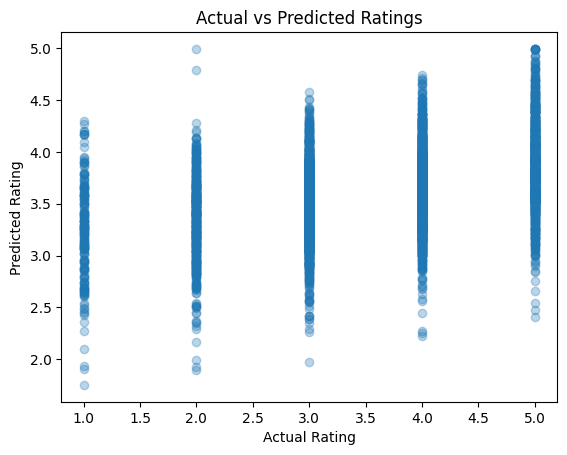

In [187]:
import matplotlib.pyplot as plt

plt.scatter(actual, predicted, alpha=0.3)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")

plt.show()

# map@10

In [188]:
relevant_movies = (
    test_df[test_df["rating"] >= 4]
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)
relevant_movies

{1533: {191,
  316,
  457,
  580,
  872,
  996,
  1110,
  2122,
  2651,
  3273,
  3385,
  3446,
  3551,
  3938,
  4306},
 1738: {299,
  436,
  1255,
  1553,
  1659,
  2040,
  2162,
  2372,
  2782,
  2800,
  2803,
  3368,
  3962,
  4098,
  4432,
  4472},
 2787: {223,
  268,
  269,
  312,
  331,
  338,
  457,
  789,
  857,
  886,
  963,
  985,
  1123,
  1202,
  1329,
  1625,
  1659,
  1798,
  1878,
  2043,
  2172,
  2290,
  2372,
  2430,
  2470,
  2743,
  2862,
  3003,
  3081,
  3138,
  3182,
  3198,
  3478,
  3624,
  3670,
  3728,
  3796,
  3903,
  3938,
  4219,
  4262,
  4306},
 3101: {118, 143, 329, 468, 483, 535, 629, 1202, 1428, 2342, 3085, 3612, 3624},
 3321: {118,
  189,
  199,
  305,
  401,
  406,
  442,
  667,
  674,
  751,
  822,
  857,
  859,
  1020,
  1035,
  1066,
  1203,
  1357,
  1467,
  1488,
  1578,
  1642,
  1744,
  1780,
  1803,
  1810,
  1918,
  1923,
  2102,
  2135,
  2139,
  2228,
  2252,
  2279,
  2471,
  2476,
  2568,
  2594,
  2654,
  2734,
  2795,
  2851,
  2862

In [189]:
def recommend_item_cf_eval(
    user_id,
    k=10,
    n_neighbors=50
):

    if user_id not in user_movie_train.index:
        return []

    watched = (
        user_movie_train
        .loc[user_id]
        .dropna()
    )

    scores = {}

    for movie_id, rating in watched.items():

        if movie_id not in similarity_df.columns:
            continue

        similar_movies = (
            similarity_df[movie_id]
            .sort_values(ascending=False)
            .iloc[1:n_neighbors+1]
        )

        for similar_movie, similarity in similar_movies.items():

            scores[similar_movie] = (
                scores.get(similar_movie, 0)
                + similarity * rating
            )

    # Remove already watched movies
    for movie_id in watched.index:
        scores.pop(movie_id, None)

    recommendations = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:k]

    return [
        movie_id
        for movie_id, score
        in recommendations
    ]

In [190]:
def average_precision_at_k(
    recommended,
    relevant,
    k=10
):

    hits = 0
    score = 0

    for i, movie_id in enumerate(
        recommended[:k],
        start=1
    ):

        if movie_id in relevant:

            hits += 1

            score += hits / i

    if len(relevant) == 0:
        return 0

    return score / min(
        len(relevant),
        k
    )

In [ ]:
import numpy as np

ap_scores = []

# Include all test users (not just those with relevant items)
all_test_users = test_df["user_id"].unique()[:1000]

for user_id in all_test_users:

    recommendations = recommend_item_cf_eval(
        user_id,
        k=10
    )

    # Users with no relevant items get AP=0
    relevant = relevant_movies.get(user_id, set())
    ap = average_precision_at_k(
        recommendations,
        relevant,
        k=10
    )

    ap_scores.append(ap)

print("MAP@10 =", np.mean(ap_scores))

MAP@10 = 0.20738894006676745


In [192]:
relevant_counts = [
    len(movies)
    for movies in relevant_movies.values()
]

print("Average relevant movies:",
      np.mean(relevant_counts))

print("Median relevant movies:",
      np.median(relevant_counts))

Average relevant movies: 19.350750750750752
Median relevant movies: 17.0


In [193]:
print(len(sample_users))
print(len(ap_scores))

1000
1000


# svd

In [194]:
cf_df.head()

,user_id,movie_id,rating,date
701,2031561,3,4,2004-03-31
710,1694958,3,3,2005-08-10
745,2312349,3,4,2003-05-13
806,2554745,3,4,2004-04-08
808,1355097,3,4,2003-03-26


In [259]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    cf_df,
    test_size=0.2,
    random_state=42
)

In [260]:
from surprise import Dataset, Reader, SVD

reader = Reader(rating_scale=(1, 5))

data = Dataset.load_from_df(
    train_df[["user_id", "movie_id", "rating"]],
    reader
)
trainset = data.build_full_trainset()

In [261]:
from surprise import SVD

model = SVD(
    n_factors=50,
    n_epochs=20,
    random_state=42
)

model.fit(trainset)

In [262]:
testset = [
    (int(row['user_id']), int(row['movie_id']), row['rating'])
    for _, row in test_df.iterrows()
]
predictions = model.test(testset)

In [263]:
from surprise import accuracy

rmse = accuracy.rmse(predictions)

RMSE: 0.8542


In [264]:
for pred in predictions[:10]:
    print(
        f"User: {pred.uid}, "
        f"Movie: {pred.iid}, "
        f"Actual: {pred.r_ui}, "
        f"Predicted: {pred.est:.2f}"
    )

User: 460258, Movie: 2690, Actual: 1, Predicted: 2.91
User: 325384, Movie: 468, Actual: 1, Predicted: 3.13
User: 2557968, Movie: 1324, Actual: 3, Predicted: 3.30
User: 2309420, Movie: 2256, Actual: 2, Predicted: 3.00
User: 1193468, Movie: 2395, Actual: 5, Predicted: 3.79
User: 1863511, Movie: 2521, Actual: 4, Predicted: 3.68
User: 1890809, Movie: 223, Actual: 1, Predicted: 3.75
User: 1596336, Movie: 1145, Actual: 1, Predicted: 2.17
User: 823520, Movie: 4306, Actual: 5, Predicted: 4.01
User: 1242044, Movie: 368, Actual: 4, Predicted: 3.13


In [265]:
def recommend_svd(user_id, k=10):

    watched_movies = set(
        cf_df[
            cf_df["user_id"] == user_id
        ]["movie_id"]
    )

    all_movies = cf_df["movie_id"].unique()

    recommendations = []

    for movie_id in all_movies:

        if movie_id in watched_movies:
            continue

        pred = model.predict(
            user_id,
            movie_id
        )

        recommendations.append(
            (movie_id, pred.est)
        )

    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:k]

In [266]:
def recommend_svd_pretty(user_id, k=10):

    recs = recommend_svd(user_id, k)

    result = []

    for movie_id, score in recs:

        result.append({
            "movie_id": movie_id,
            "title": movie_lookup.get(movie_id, "Unknown"),
            "predicted_rating": round(score, 3)
        })

    return pd.DataFrame(result)

In [267]:
recommend_svd_pretty(1533)

,movie_id,title,predicted_rating
0,2040,Star Trek: The Next Generation: Season 5,4.750
1,2195,The Looney Tunes Golden Collection: Vol. 2,4.732
2,68,Invader Zim,4.719
3,3928,Nip/Tuck: Season 2,4.707
4,4383,Farscape: The Peacekeeper Wars,4.705
5,4427,The West Wing: Season 3,4.699
6,839,The Thin Man Goes Home,4.675
7,4045,The Indiana Jones Trilogy: Bonus Material,4.654
8,3456,Lost: Season 1,4.644
9,1795,MASH: Season 7,4.644


In [268]:
print(user_movie.index[:10])

Index([1533, 1738, 2787, 3101, 3321, 3461, 4753, 5430, 5530, 5916], dtype='int64', name='user_id')


In [269]:
recommend(1533)

,movie_id,title,score
0,798,Jaws,100.039814
1,985,The Mummy,93.760505
2,2095,Liar Liar,93.330843
3,3106,Ghost,92.167240
4,4356,Road to Perdition,83.802418
5,1542,Sleepless in Seattle,74.520951
6,1428,The Recruit,73.106179
7,2112,Identity,71.443012
8,1202,National Lampoon's Vacation,70.769769
9,3825,The Sum of All Fears,70.580928


# MAP

In [270]:
train_df

,user_id,movie_id,rating,date
19410329,906476,3689,5,2005-10-10
20624870,86636,3905,3,2005-03-24
15833650,1576186,3084,3,2005-01-29
20140727,1621025,3840,2,2003-01-08
17035828,1392047,3285,4,2005-04-06
...,...,...,...,...
6900605,896114,1367,3,2002-01-08
9651204,1318976,1901,5,2004-01-10
3542575,516192,681,3,2005-08-03
17819852,1936049,3418,5,2004-06-04


In [271]:
test_df

,user_id,movie_id,rating,date
14007478,460258,2690,1,2004-08-28
2508411,325384,468,1,2004-04-12
6809620,2557968,1324,3,2004-05-12
11800787,2309420,2256,2,2003-04-21
12539158,1193468,2395,5,2004-01-01
...,...,...,...,...
16859479,1159363,3272,4,2004-02-16
3806959,2118461,723,5,2005-10-23
4621567,867967,896,4,2005-07-13
14273525,1086481,2757,3,2004-01-18


In [272]:

relevant_movies = (
    test_df[test_df["rating"] >= 4]
    .groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

In [273]:
relevant_movies

{1533: {191,
  316,
  457,
  580,
  872,
  996,
  1110,
  2122,
  2651,
  3273,
  3385,
  3446,
  3551,
  3938,
  4306},
 1738: {299,
  436,
  1255,
  1553,
  1659,
  2040,
  2162,
  2372,
  2782,
  2800,
  2803,
  3368,
  3962,
  4098,
  4432,
  4472},
 2787: {223,
  268,
  269,
  312,
  331,
  338,
  457,
  789,
  857,
  886,
  963,
  985,
  1123,
  1202,
  1329,
  1625,
  1659,
  1798,
  1878,
  2043,
  2172,
  2290,
  2372,
  2430,
  2470,
  2743,
  2862,
  3003,
  3081,
  3138,
  3182,
  3198,
  3478,
  3624,
  3670,
  3728,
  3796,
  3903,
  3938,
  4219,
  4262,
  4306},
 3101: {118, 143, 329, 468, 483, 535, 629, 1202, 1428, 2342, 3085, 3612, 3624},
 3321: {118,
  189,
  199,
  305,
  401,
  406,
  442,
  667,
  674,
  751,
  822,
  857,
  859,
  1020,
  1035,
  1066,
  1203,
  1357,
  1467,
  1488,
  1578,
  1642,
  1744,
  1780,
  1803,
  1810,
  1918,
  1923,
  2102,
  2135,
  2139,
  2228,
  2252,
  2279,
  2471,
  2476,
  2568,
  2594,
  2654,
  2734,
  2795,
  2851,
  2862

In [274]:
train_user_movies = (
    train_df.groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

In [275]:
train_user_movies

{1533: {33,
  175,
  208,
  238,
  257,
  330,
  468,
  571,
  607,
  788,
  850,
  940,
  964,
  1180,
  1220,
  1470,
  1495,
  1571,
  1572,
  1578,
  1625,
  1741,
  1798,
  1799,
  1905,
  1918,
  1962,
  1975,
  2057,
  2102,
  2114,
  2152,
  2172,
  2430,
  2452,
  2465,
  2532,
  2568,
  2660,
  2675,
  2699,
  2779,
  2782,
  2862,
  2890,
  2992,
  3046,
  3151,
  3197,
  3333,
  3371,
  3567,
  3610,
  3624,
  3684,
  3715,
  3860,
  3879,
  3881,
  3925,
  3962,
  4043,
  4089,
  4094,
  4123,
  4141,
  4266,
  4392,
  4432},
 1738: {30,
  191,
  197,
  329,
  331,
  457,
  473,
  550,
  571,
  607,
  615,
  692,
  711,
  752,
  758,
  788,
  843,
  896,
  985,
  1020,
  1144,
  1145,
  1180,
  1202,
  1220,
  1307,
  1406,
  1470,
  1542,
  1561,
  1571,
  1585,
  1590,
  1615,
  1637,
  1645,
  1682,
  1754,
  1798,
  1865,
  1905,
  2000,
  2057,
  2112,
  2152,
  2186,
  2252,
  2290,
  2389,
  2391,
  2395,
  2452,
  2457,
  2470,
  2499,
  2577,
  2580,
  2612,
  266

In [276]:
def recommend_svd_eval(user_id, k=10):

    watched_movies = train_user_movies.get(
        user_id,
        set()
    )

    all_movies = train_df["movie_id"].unique()

    recommendations = []

    for movie_id in all_movies:

        if movie_id in watched_movies:
            continue

        pred = model.predict(
            user_id,
            movie_id
        )

        recommendations.append(
            (movie_id, pred.est)
        )

    recommendations.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return [
        movie_id
        for movie_id, score
        in recommendations[:k]
    ]

In [277]:
def average_precision_at_k(
    recommended,
    relevant,
    k=10
):

    hits = 0
    score = 0

    for i, movie_id in enumerate(
        recommended[:k],
        start=1
    ):

        if movie_id in relevant:

            hits += 1

            score += hits / i

    if len(relevant) == 0:
        return 0

    return score / min(
        len(relevant),
        k
    )

In [278]:
ap_scores = []

sample_users = list(relevant_movies.items())[:1000]


for user_id, relevant in sample_users:

    recommendations = recommend_svd_eval(
        user_id,
        k=10
    )

    ap = average_precision_at_k(
        recommendations,
        relevant,
        k=10
    )

    ap_scores.append(ap)

In [279]:
import numpy as np

map10 = np.mean(ap_scores)

print("MAP@10 =", map10)

MAP@10 = 0.02414180776014109


In [280]:
print(len(ap_scores))
print(len(relevant_movies))

1000
4995
